# Chicago Taxi Data – Exploratory Data Analysis

**Project:** AAA Team Assignment – Ride-Hailing for Electric Vehicle Fleet  
**Dataset:** Chicago Taxi Trips 2025 (Chicago Data Portal)  
**Vorverarbeitung:** Cleaning erfolgt in `00_data_loading.ipynb` → Eingabe: `chicago_taxi_2025_clean.parquet`

### Notebook Structure
1. Setup & Data Loading
2. Basic Dataset Overview
3. Temporal Patterns
4. Trip Characteristics (Distance, Duration, Price)
5. Spatial Overview
6. Idle Time Between Trips
7. Key Takeaways

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Load cleaned data ─────────────────────────────────────────────────────────
PARQUET_PATH = '../data/chicago_taxi_2025_clean.parquet'

print(f'Loading: {PARQUET_PATH}')
df_2025_clean = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(df_2025_clean):,} rows and {df_2025_clean.shape[1]} columns.')
df_2025_clean.head(10)

Loading: ../data/chicago_taxi_2025_clean.parquet
Loaded 5,708,264 rows and 12 columns.


,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,fare,trip_total
0,2025-01-07 23:45:00,2025-01-08 00:00:00,1405.0,14.84,76,6,41.980264,-87.913625,41.944227,-87.655998,36.75,49.50
1,2025-01-07 23:45:00,2025-01-08 00:00:00,318.0,1.30,8,8,41.899602,-87.633308,41.899602,-87.633308,6.50,6.50
2,2025-01-07 23:45:00,2025-01-07 23:45:00,419.0,0.87,8,8,41.899602,-87.633308,41.899602,-87.633308,6.25,10.75
3,2025-01-07 23:45:00,2025-01-08 00:00:00,1272.0,14.37,76,22,41.980264,-87.913625,41.922761,-87.699155,36.00,48.60
4,2025-01-07 23:45:00,2025-01-08 00:00:00,1368.0,17.25,76,28,41.980264,-87.913625,41.874005,-87.663518,42.75,57.90
5,2025-01-07 23:45:00,2025-01-07 23:45:00,719.0,11.78,40,54,41.792357,-87.617931,41.660136,-87.602848,29.75,29.75
6,2025-01-07 23:45:00,2025-01-08 00:00:00,1211.0,14.58,76,7,41.980264,-87.913625,41.922686,-87.649489,36.75,49.50
7,2025-01-07 23:45:00,2025-01-08 00:00:00,1148.0,10.87,8,68,41.899602,-87.633308,41.777196,-87.642498,28.75,28.75
8,2025-01-07 23:45:00,2025-01-08 00:00:00,711.0,5.61,8,6,41.899602,-87.633308,41.944227,-87.655998,16.50,21.25
9,2025-01-07 23:45:00,2025-01-08 00:00:00,960.0,11.10,3,36,41.965812,-87.655879,41.823713,-87.602350,28.50,28.50


## 2. Basic Dataset Overview

In [3]:
# Schema: column names, dtypes, non-null counts
print('=== Dataset Info ===')
df_2025_clean.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5708264 entries, 0 to 5708263
Data columns (total 12 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_start_timestamp        datetime64[ns]
 1   trip_end_timestamp          datetime64[ns]
 2   trip_seconds                float64       
 3   trip_miles                  float64       
 4   pickup_community_area       int64         
 5   dropoff_community_area      int64         
 6   pickup_centroid_latitude    float64       
 7   pickup_centroid_longitude   float64       
 8   dropoff_centroid_latitude   float64       
 9   dropoff_centroid_longitude  float64       
 10  fare                        float64       
 11  trip_total                  float64       
dtypes: datetime64[ns](2), float64(8), int64(2)
memory usage: 522.6 MB


In [4]:
# Date range covered by the dataset
print(f'Earliest trip : {df_2025_clean["trip_start_timestamp"].min()}')
print(f'Latest trip   : {df_2025_clean["trip_start_timestamp"].max()}')

Earliest trip : 2025-01-01 00:00:00
Latest trip   : 2025-12-31 23:45:00


## 3. Temporal Patterns

In [5]:
# Extract temporal features
df_2025_clean['hour']         = df_2025_clean['trip_start_timestamp'].dt.hour
df_2025_clean['weekday']      = df_2025_clean['trip_start_timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
df_2025_clean['weekday_name'] = df_2025_clean['trip_start_timestamp'].dt.day_name()
df_2025_clean['month']        = df_2025_clean['trip_start_timestamp'].dt.month
df_2025_clean['month_name']   = df_2025_clean['trip_start_timestamp'].dt.month_name()
df_2025_clean['is_weekend']   = df_2025_clean['weekday'].isin([5, 6])
df_2025_clean['date']         = df_2025_clean['trip_start_timestamp'].dt.date

print('Temporal features added.')

Temporal features added.


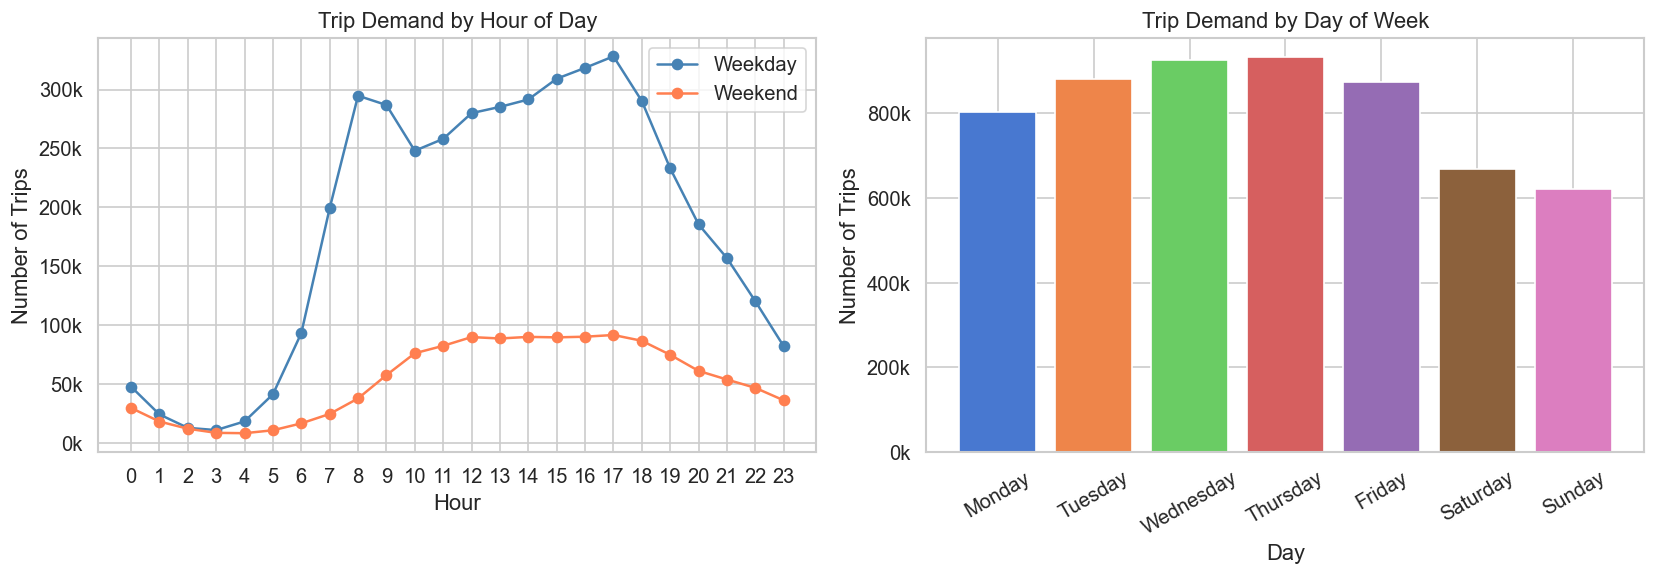

In [6]:
# ── Trips per hour of day ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekday vs Weekend
hourly = df_2025_clean.groupby(['hour', 'is_weekend']).size().reset_index(name='trips')
for is_we, label, color in [(False, 'Weekday', 'steelblue'), (True, 'Weekend', 'coral')]:
    subset = hourly[hourly['is_weekend'] == is_we]
    axes[0].plot(subset['hour'], subset['trips'], marker='o', label=label, color=color)
axes[0].set_title('Trip Demand by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# By day of week
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
trips_by_day = df_2025_clean.groupby('weekday_name').size().reindex(weekday_order)
axes[1].bar(trips_by_day.index, trips_by_day.values, color=sns.color_palette('muted'))
axes[1].set_title('Trip Demand by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

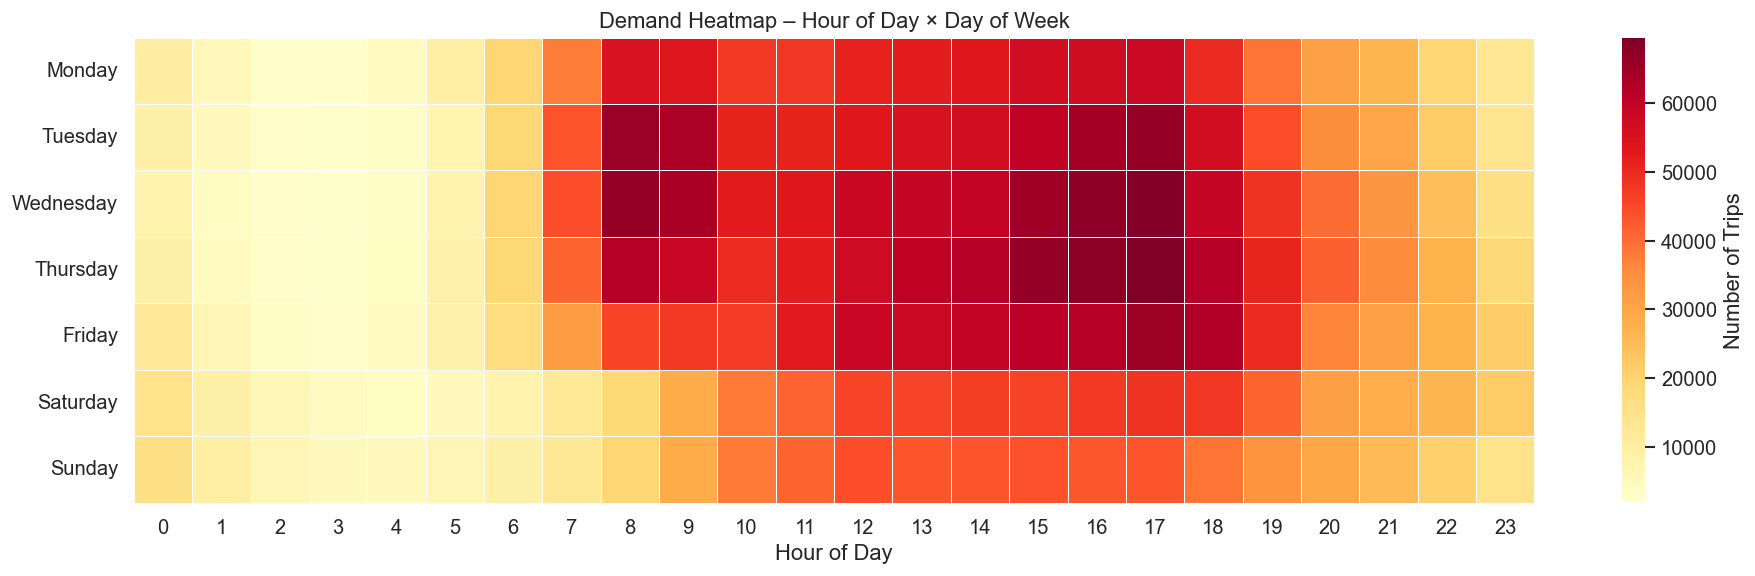

In [7]:
# ── Heatmap: hour × weekday ───────────────────────────────────────────────────
pivot = df_2025_clean.pivot_table(index='weekday_name', columns='hour', values='trip_miles',
                                   aggfunc='count')
pivot = pivot.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Number of Trips'})
ax.set_title('Demand Heatmap – Hour of Day × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

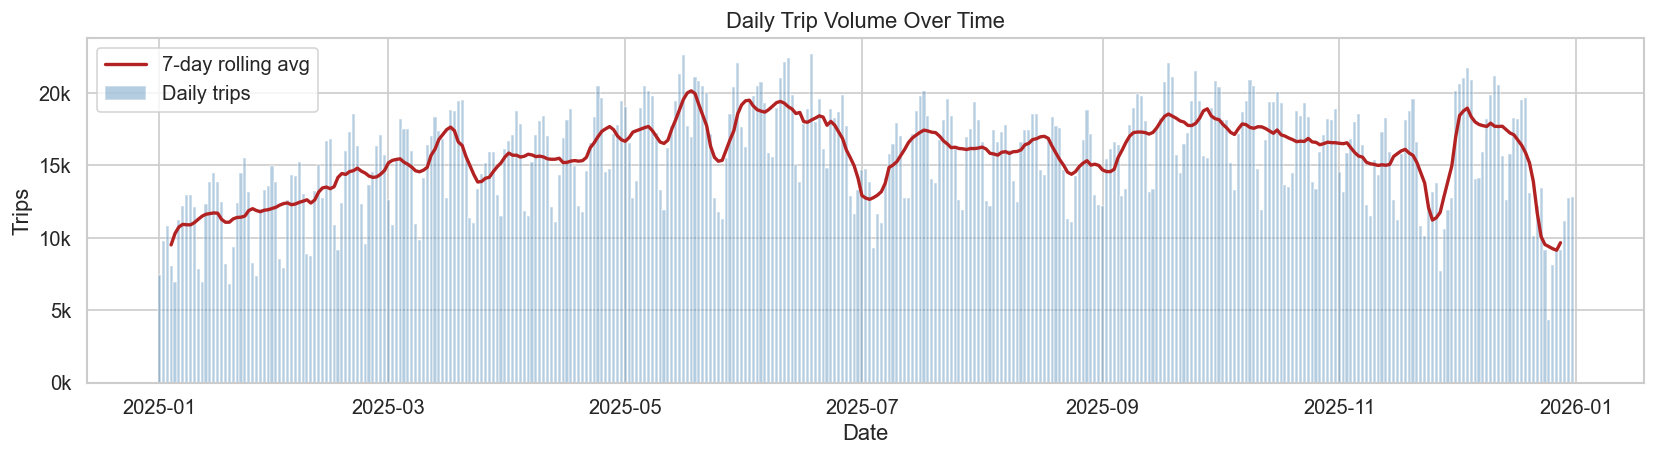

In [8]:
# ── Daily trip volume over time ───────────────────────────────────────────────
daily_trips = df_2025_clean.groupby('date').size().reset_index(name='trips')
daily_trips['date'] = pd.to_datetime(daily_trips['date'])
daily_trips['rolling_7d'] = daily_trips['trips'].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_trips['date'], daily_trips['trips'], color='steelblue', alpha=0.4, label='Daily trips')
ax.plot(daily_trips['date'], daily_trips['rolling_7d'], color='firebrick', linewidth=2, label='7-day rolling avg')
ax.set_title('Daily Trip Volume Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

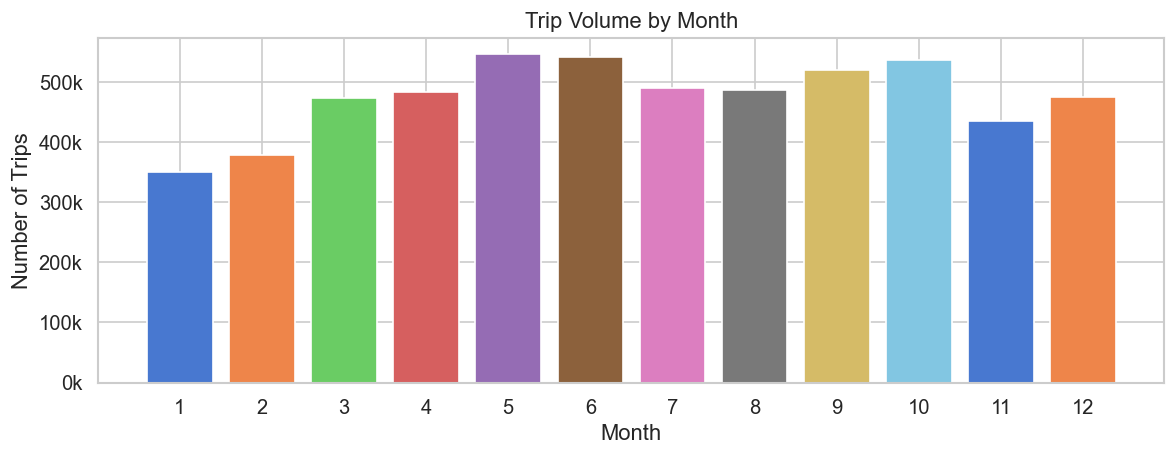

In [9]:
# ── Monthly trip volume ───────────────────────────────────────────────────────
monthly = df_2025_clean.groupby('month').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index, monthly.values, color=sns.color_palette('muted'))
ax.set_title('Trip Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.set_xticks(monthly.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

## 4. Trip Characteristics – Distance, Duration & Price

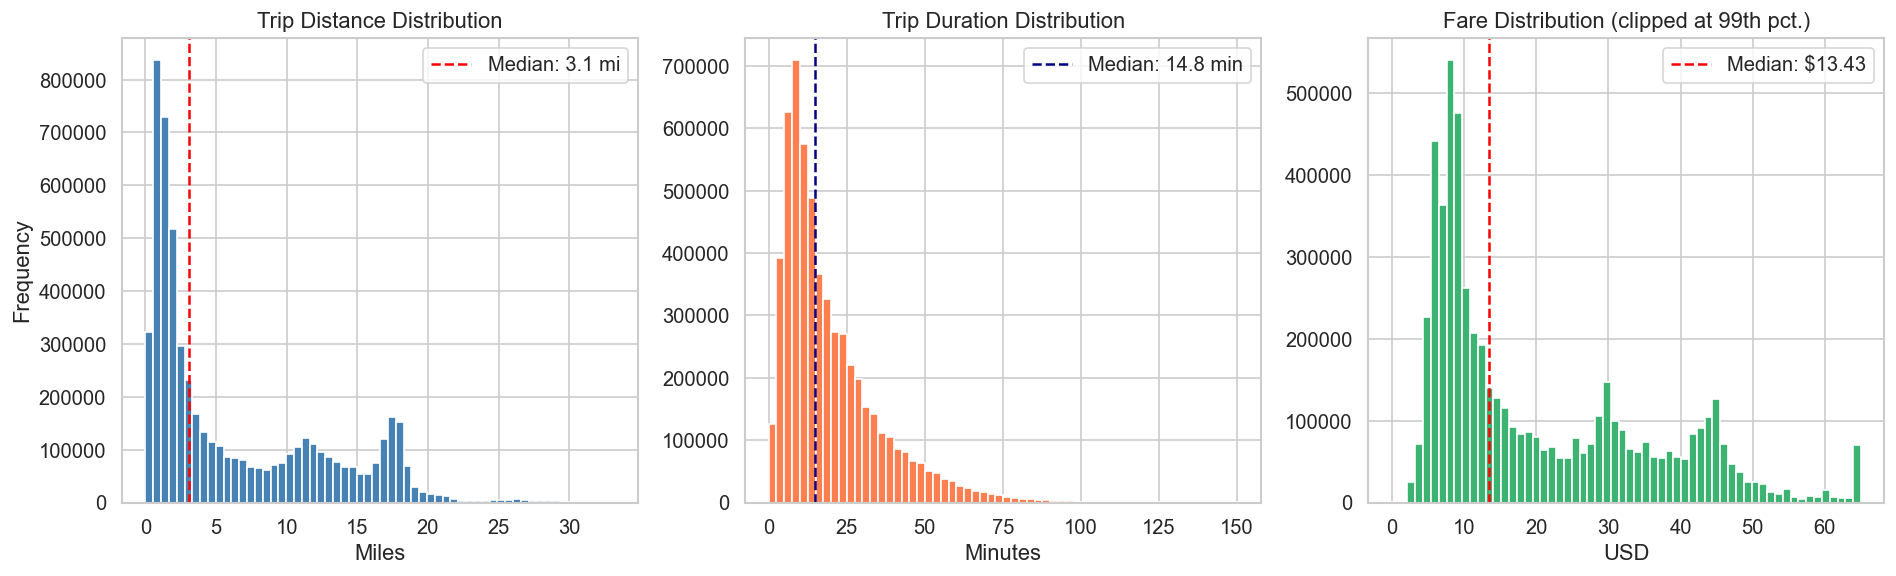

       trip_miles  trip_minutes        fare  trip_total
count  5708264.00    5708264.00  5708264.00  5708264.00
mean         6.36         19.82       20.38       24.20
std          6.33         15.94       15.88       19.52
min          0.01          0.02        0.01        0.01
25%          1.30          8.53        8.50       10.14
50%          3.12         14.78       13.43       15.45
75%         11.25         26.50       30.75       32.50
max         33.20        150.30     6950.69     6950.69


In [10]:
# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distance
axes[0].hist(df_2025_clean['trip_miles'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Trip Distance Distribution')
axes[0].set_xlabel('Miles')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_2025_clean['trip_miles'].median(), color='red', linestyle='--',
                label=f'Median: {df_2025_clean["trip_miles"].median():.1f} mi')
axes[0].legend()

# Duration (in minutes)
df_2025_clean['trip_minutes'] = df_2025_clean['trip_seconds'] / 60
axes[1].hist(df_2025_clean['trip_minutes'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Trip Duration Distribution')
axes[1].set_xlabel('Minutes')
axes[1].axvline(df_2025_clean['trip_minutes'].median(), color='navy', linestyle='--',
                label=f'Median: {df_2025_clean["trip_minutes"].median():.1f} min')
axes[1].legend()

# Fare
axes[2].hist(df_2025_clean['fare'].clip(upper=df_2025_clean['fare'].quantile(0.99)), bins=60,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Fare Distribution (clipped at 99th pct.)')
axes[2].set_xlabel('USD')
axes[2].axvline(df_2025_clean['fare'].median(), color='red', linestyle='--',
                label=f'Median: ${df_2025_clean["fare"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(df_2025_clean[['trip_miles', 'trip_minutes', 'fare', 'trip_total']].describe().round(2))

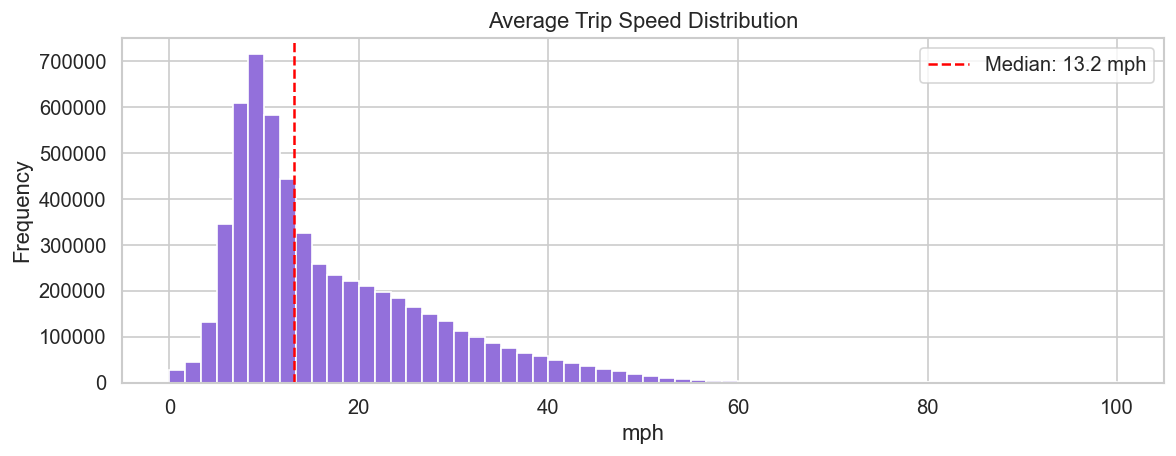

In [11]:
# ── Average speed (mph) ────────────────────────────────────────────────────────
df_2025_clean['speed_mph'] = (df_2025_clean['trip_miles'] / (df_2025_clean['trip_seconds'] / 3600)).clip(upper=100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_2025_clean['speed_mph'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
ax.axvline(df_2025_clean['speed_mph'].median(), color='red', linestyle='--',
           label=f'Median: {df_2025_clean["speed_mph"].median():.1f} mph')
ax.set_title('Average Trip Speed Distribution')
ax.set_xlabel('mph')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

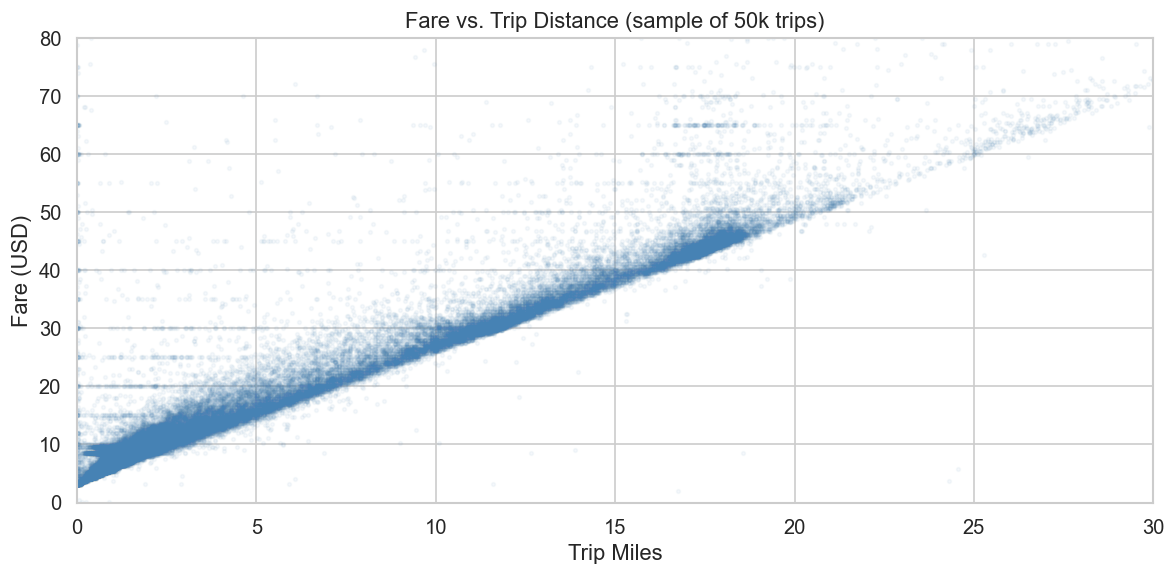

In [12]:
# ── Fare vs. Distance scatterplot (sampled for performance) ───────────────────
sample = df_2025_clean.sample(min(50_000, len(df_2025_clean)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['trip_miles'], sample['fare'], alpha=0.05, s=5, color='steelblue')
ax.set_title('Fare vs. Trip Distance (sample of 50k trips)')
ax.set_xlabel('Trip Miles')
ax.set_ylabel('Fare (USD)')
ax.set_xlim(0, 30)
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

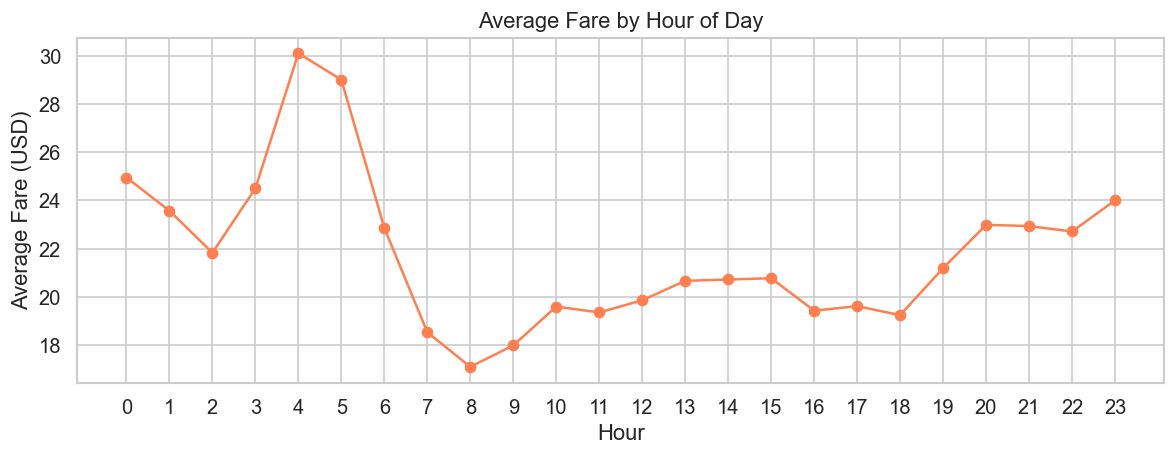

In [13]:
# ── Average fare by hour of day ───────────────────────────────────────────────
avg_fare_hour = df_2025_clean.groupby('hour')['fare'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_fare_hour.index, avg_fare_hour.values, marker='o', color='coral')
ax.set_title('Average Fare by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Average Fare (USD)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 5. Spatial Overview
A first look at where trips start and end across Chicago.

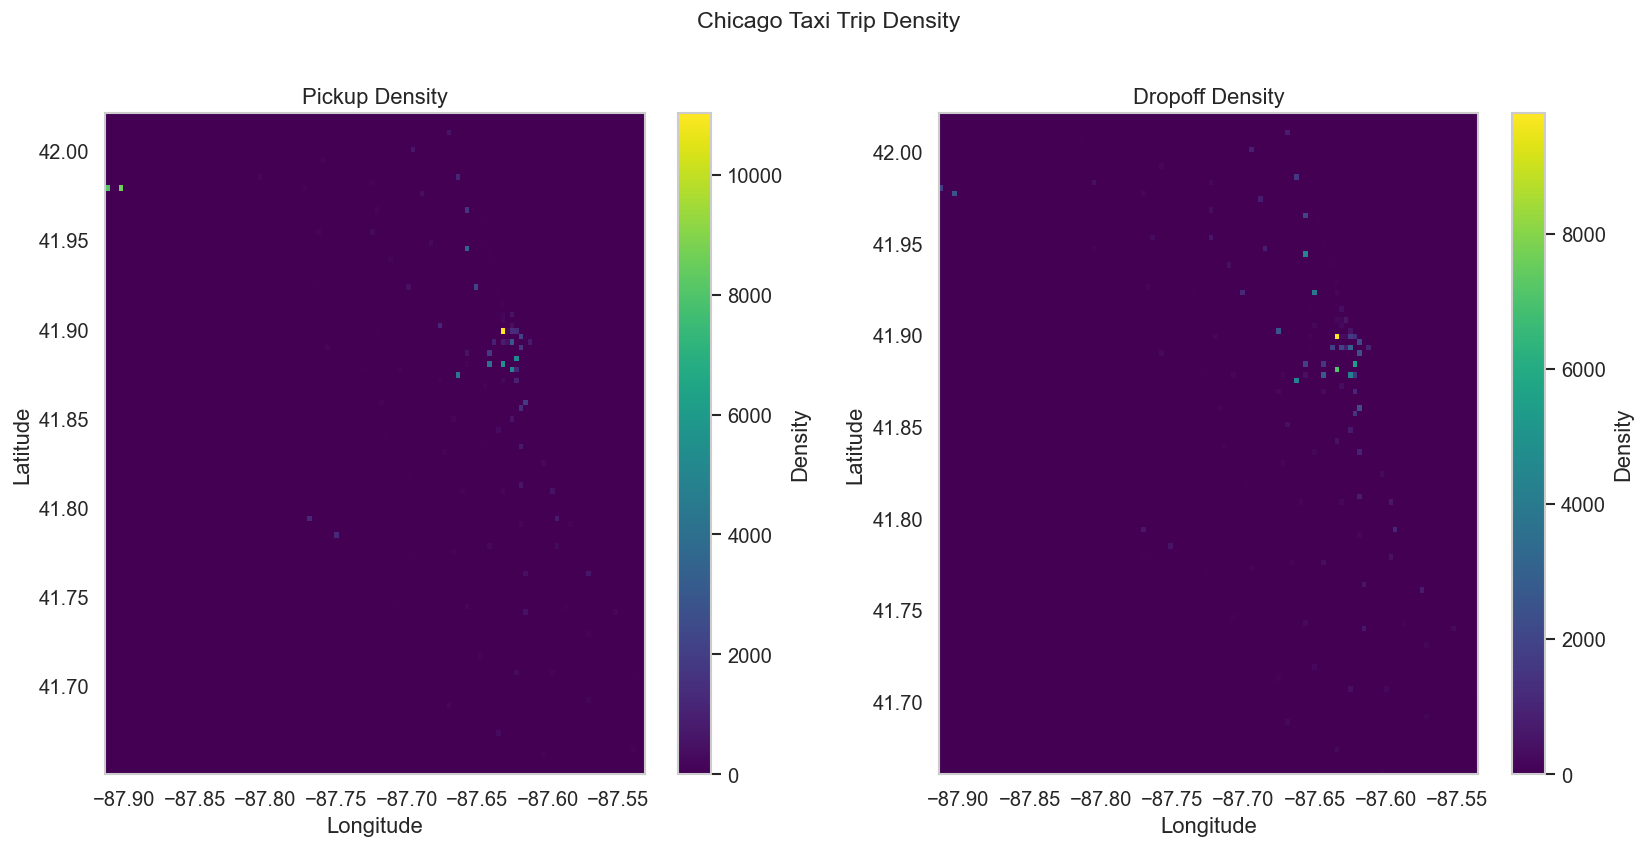

Trips with valid pickup coordinates: 5,708,264


In [14]:
# ── Trip density map (2D histogram) ──────────────────────────────────────────
LAT_MIN, LAT_MAX = 41.6, 42.1
LON_MIN, LON_MAX = -87.95, -87.5

spatial = df_2025_clean[
    df_2025_clean['pickup_centroid_latitude'].between(LAT_MIN, LAT_MAX) &
    df_2025_clean['pickup_centroid_longitude'].between(LON_MIN, LON_MAX)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, lat_col, lon_col, title in [
    (axes[0], 'pickup_centroid_latitude',  'pickup_centroid_longitude',  'Pickup Density'),
    (axes[1], 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'Dropoff Density'),
]:
    h = ax.hist2d(
        spatial[lon_col].dropna(),
        spatial[lat_col].dropna(),
        bins=120,
        cmap='viridis',
        density=True,
    )
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Chicago Taxi Trip Density', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trips with valid pickup coordinates: {len(spatial):,}')

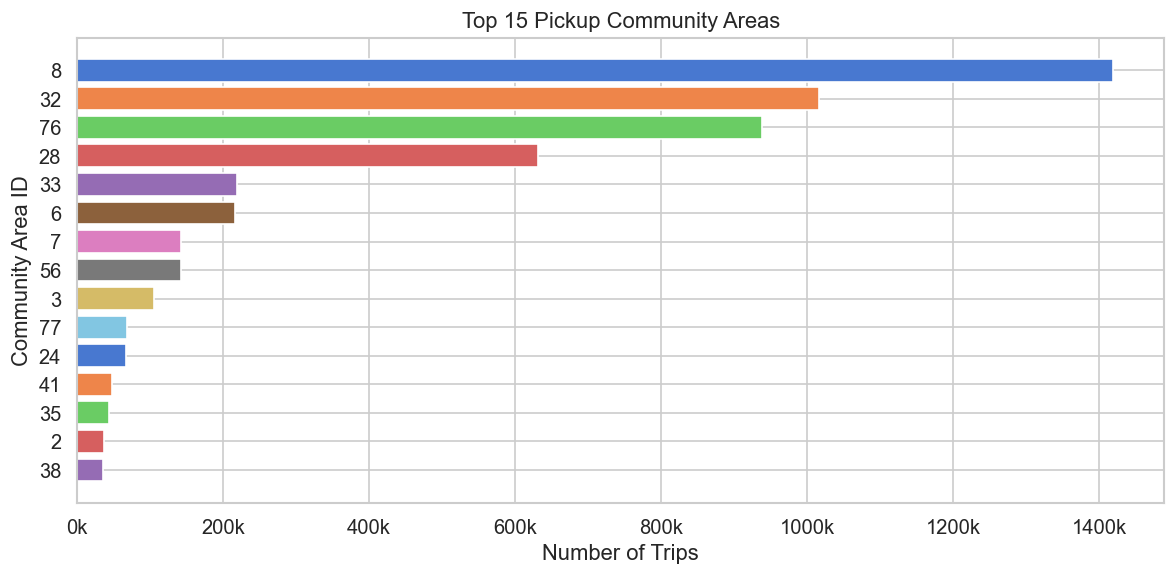

In [15]:
# ── Top 15 pickup community areas ─────────────────────────────────────────────
top_pickup = (
    df_2025_clean['pickup_community_area']
    .value_counts()
    .head(15)
    .reset_index()
)
top_pickup.columns = ['community_area', 'trips']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_pickup['community_area'].astype(str), top_pickup['trips'],
               color=sns.color_palette('muted', 15))
ax.invert_yaxis()
ax.set_title('Top 15 Pickup Community Areas')
ax.set_xlabel('Number of Trips')
ax.set_ylabel('Community Area ID')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()